# Visualization Quality Metrics: *Synthetic Data*

This notebook computes Trustworthiness, Continuity, Spearman Correlation, and DEMaP for each dimensionality reduction method (PCA, UMAP, PHATE, PaCMAP, TriMAP, t-SNE) on LLM-generated synthetic hierarchical datasets, for both `all-MiniLM-L6-v2` and `Qwen3-Embedding-0.6B` embeddings.

Embeddings are loaded from precomputed `.npy` files generated by `eval_script.py`. 2D reductions are computed and cached in `cache/{embedding_model}_reduced_2d/`. Results are saved to `../results/viz_metrics/{embedding_model}/`.

## Methodology

### Dimensionality Reduction
Six DR methods are evaluated on LLM-generated synthetic ecological text datasets with known hierarchical structure. Each method is applied directly to sentence embeddings to produce 2D representations:

- **PCA**: Linear projection via SVD (scikit-learn).
- **UMAP**: Nonlinear manifold learning with `n_neighbors=10`, `min_dist=0.05` (McInnes et al., 2018).
- **PHATE**: Diffusion-based method for continuous and hierarchical structure (Moon et al., 2019).
- **PaCMAP**: Preserves local and global structure via mid-near pair sampling (Wang et al., 2021).
- **TriMAP**: Uses triplet constraints to preserve global structure (Amid & Warmuth, 2019).
- **t-SNE**: Nonlinear method for local cluster separation. Following standard practice (van der Maaten & Hinton, 2008), embeddings are first reduced to 50 dimensions with PCA before applying t-SNE. To ensure all configs are processed identically, scikit-learn's TSNE is used for all synthetic datasets with `init='pca'`, `learning_rate='auto'`, `max_iter=2000`, `perplexity=min(30, n//4)`, and `random_state=67`. (RAPIDS cuML TSNE, used in early runs on HPCC, produced degenerate near-zero output on smaller configs and was replaced entirely.)

### Synthetic Dataset Variants
Datasets are generated across two topics (Ecosystems, Fisheries), two hierarchy shapes (deep: depth=5/maxsub=3; shallow: depth=3/maxsub=5), and three noise levels (0%, 25%, 50% label noise).

### Visualization Quality Metrics
- **Trustworthiness**: Local structure preservation (k-NN in 2D vs high-dim). Range: [0,1].
- **Continuity**: Reverse of trustworthiness. Range: [0,1].
- **Spearman Correlation**: Rank correlation of pairwise Euclidean distances high-dim vs 2D.
- **DEMaP** (Moon et al., 2019): Spearman correlation of geodesic vs Euclidean distances.

### Caching
2D reductions cached as `.npy` files. Metrics saved incrementally after each method.

### References
- van der Maaten, L., & Hinton, G. (2008). Visualizing data using t-SNE. *JMLR*, 9, 2579-2605.
- McInnes, L., et al. (2018). UMAP. *arXiv:1802.03426*.
- Moon, K.R., et al. (2019). PHATE. *Nature Biotechnology*, 37, 1482-1492.
- Wang, Y., et al. (2021). PaCMAP. *JMLR*, 22(201), 1-73.
- Amid, E., & Warmuth, M.K. (2019). TriMAP. *arXiv:1910.00204*.
- Venna, J., & Kaski, S. (2001). Neighborhood preservation. *ICANN*, 485-491.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import phate
import pacmap
import trimap
import umap as umap_pkg
from sklearn.manifold import TSNE as skTSNE
from sklearn.decomposition import PCA as skPCA
from sklearn.manifold import trustworthiness
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from scipy.stats import spearmanr

# navigate to src/ from wherever the notebook is run
current = os.path.abspath('.')
while os.path.basename(current) != 'src' and current != os.path.dirname(current):
    current = os.path.dirname(current)
src_dir = current
os.chdir(src_dir)
sys.path.insert(0, src_dir)

## 1. Setup

Change the parameters here to select which synthetic dataset to evaluate. The `stem` variable is automatically built from the config. Available themes: `Energy_Ecosystems_and_Humans`, `Offshore_energy_impacts_on_fisheries`.

In [2]:
# config: change these parameters to match the synthetic dataset you want to evaluate
embedding_model  = "sentence-transformers/all-MiniLM-L6-v2" # options: sentence-transformers/all-MiniLM-L6-v2, Qwen/Qwen3-Embedding-0.6B
theme            = "Energy_Ecosystems_and_Humans"  # options: Energy_Ecosystems_and_Humans, Offshore_energy_impacts_on_fisheries
t                = 1.0
max_sub          = 3 #  options: 3, 5
depth            = 5 #  options: 3, 5
synonyms         = 0
branching        = "random"
add_noise        = 0.25

# build filename stem from config
if add_noise > 0:
    stem = f"{theme}_hierarchy_t{t}_maxsub{max_sub}_depth{depth}_synonyms{synonyms}_noise{add_noise}_{branching}"
else:
    stem = f"{theme}_hierarchy_t{t}_maxsub{max_sub}_depth{depth}_synonyms{synonyms}_{branching}"

embedding_dir = f"cache/{embedding_model}_embeddings"
reduction_dir = f"cache/{embedding_model}_reduced_embeddings"
results_dir   = f"../results/viz_metrics/{embedding_model}"
shepard_dir   = f"../results/shepard_diagrams/{embedding_model}"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(shepard_dir, exist_ok=True)

print(f"Stem: {stem}")
print(f"Embedding dir: {embedding_dir}")
print(f"Reduction dir: {reduction_dir}")
print(f"Results dir:   {results_dir}")
print(f"Shepard dir:   {shepard_dir}")

Stem: Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random
Embedding dir: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_embeddings
Reduction dir: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_embeddings
Results dir:   intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results


## 2. Load Embeddings

Load precomputed embeddings from `eval_script.py` output. To generate these, run:

```bash
python src/run_models/synthetic_data/eval_script.py --theme Energy_Ecosystems_and_Humans --t 1.0 --max_sub 3 --depth 5 --synonyms 0 --branching random
```

In [3]:
# load precomputed high-dimensional embeddings
embed_path = f"{embedding_dir}/{stem}_embed.npy"
x_high = np.load(embed_path)
print(f"Embeddings shape: {x_high.shape}")

Embeddings shape: (2000, 384)


## 3. Compute 2D Reductions

Six methods are run natively at 2D directly from the high-dimensional embeddings:

- **PCA**: SVD-based, components ordered by variance — valid to slice first 2 dimensions
- **PHATE**: metric MDS with diffusion geometry at `n_components=2` — valid to slice
- **UMAP**: optimization-based, no component ordering — must be run directly at 2D
- **PaCMAP**: optimization-based, no component ordering — must be run directly at 2D
- **TriMAP**: triplet-based global structure preservation — run directly at 2D
- **t-SNE**: scikit-learn TSNE for all configs — `init='pca'`, `learning_rate='auto'`, `max_iter=2000`, `perplexity=min(30, n//4)`, `random_state=67`; PCA preprocessed to 50 dims before TSNE

Results are cached in `cache/{embedding_model}_reduced_2d/` for fast re-runs. Synthetic datasets are all under 3500 points so no subsampling is needed.

In [4]:
reduction_2d_dir = f"cache/{embedding_model}_reduced_2d"
os.makedirs(reduction_2d_dir, exist_ok=True)

# subsample for large datasets before running 2D reductions (pairwise distances scale as n^2)
# synthetic datasets in this project are all under 3500 points so subsampling will not occur
max_samples = 5000
if x_high.shape[0] > max_samples:
    np.random.seed(42)
    sub_idx = np.random.choice(x_high.shape[0], max_samples, replace=False)
    x_high_sub = x_high[sub_idx]
    print(f"Subsampled to {max_samples} points for 2D reduction and metrics")
else:
    x_high_sub = x_high
    print(f"No subsampling needed ({x_high.shape[0]} points)")

def load_or_compute_2d(name, path, compute_fn):
    if os.path.exists(path):
        print(f"Loading cached 2D {name} from {path}...")
        return np.load(path)
    print(f"Computing 2D {name}...")
    result = compute_fn()
    np.save(path, result)
    print(f"Saved to {path}")
    return result

reductions = {}

reductions["PCA"] = load_or_compute_2d(
    "PCA", f"{reduction_2d_dir}/PCA_2d_{stem}.npy",
    lambda: skPCA(n_components=2, random_state=67).fit_transform(x_high_sub)
)
reductions["UMAP"] = load_or_compute_2d(
    "UMAP", f"{reduction_2d_dir}/UMAP_2d_{stem}.npy",
    lambda: umap_pkg.UMAP(n_components=2, min_dist=0.05, n_neighbors=10, random_state=67).fit_transform(x_high_sub)
)
reductions["PHATE"] = load_or_compute_2d(
    "PHATE", f"{reduction_2d_dir}/PHATE_2d_{stem}.npy",
    lambda: phate.PHATE(n_jobs=-2, random_state=67, n_components=2).fit_transform(x_high_sub)
)
reductions["PaCMAP"] = load_or_compute_2d(
    "PaCMAP", f"{reduction_2d_dir}/PaCMAP_2d_{stem}.npy",
    lambda: pacmap.PaCMAP(n_components=2, random_state=67).fit_transform(x_high_sub)
)
reductions["TriMAP"] = load_or_compute_2d(
    "TriMAP", f"{reduction_2d_dir}/TriMAP_2d_{stem}.npy",
    lambda: trimap.TRIMAP(n_dims=2).fit_transform(x_high_sub)
)
reductions["tSNE"] = load_or_compute_2d(
    "tSNE", f"{reduction_2d_dir}/tSNE_2d_{stem}.npy",
    lambda: skTSNE(
        n_components=2, init='pca', learning_rate='auto',
        max_iter=2000,
        perplexity=min(30, x_high_sub.shape[0] // 4),
        random_state=67,
    ).fit_transform(skPCA(n_components=min(50, x_high_sub.shape[1]), random_state=67).fit_transform(x_high_sub))
)

for name, arr in reductions.items():
    print(f"{name}: {arr.shape}")

No subsampling needed (2000 points)
Loading cached 2D PCA from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PCA_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.npy...
Loading cached 2D UMAP from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/UMAP_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.npy...
Loading cached 2D PHATE from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PHATE_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.npy...
Loading cached 2D PaCMAP from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/PaCMAP_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.npy...
Loading cached 2D TriMAP from intermediate_data/sentence-transformers/all-MiniLM-L6-v2_reduced_2d/TriMAP_2d_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synon

## 4. Metrics

- **Trustworthiness**: measures whether neighbors in low-dim space were also neighbors in high-dim space (local structure preservation)
- **Continuity**: measures whether neighbors in high-dim space are preserved in low-dim space (reverse of trustworthiness)
- **Spearman Correlation**: rank correlation of raw pairwise Euclidean distances high-dim vs 2D
- **DEMaP** (Moon et al. 2019): Spearman correlation of geodesic distances (k-NN shortest paths) in high-dim vs Euclidean distances in 2D; better captures true manifold structure than raw Euclidean. Uses the minimum K for which the k-NN graph is fully connected (no infinite geodesic distances).

Trustworthiness and Continuity range from 0 to 1, higher is better. Spearman and DEMaP range from -1 to 1, where 1 is perfect preservation and 0 means no relationship.

The synthetic datasets have explicit hierarchical structure, so higher DEMaP scores are expected when the hierarchy is well-separated in embedding space. Noise (25%, 50%) adds off-topic sentences that blur topic boundaries and is expected to degrade Spearman and DEMaP while leaving Trustworthiness and Continuity relatively stable.

**Note on variability estimation**: The benchmark notebook (`visualization_metrics.ipynb`) reports mean ± std via subsampling (30 draws of 10,000 points) for large datasets. Synthetic datasets range from 745 to 3500 points, so subsampling is not applicable — metrics are computed once on the full set.

In [5]:
def compute_continuity(x_high, x_low, n_neighbors=15):
    n = x_high.shape[0]

    d_high = pairwise_distances(x_high)
    d_low  = pairwise_distances(x_low)
    rank_low = np.argsort(np.argsort(d_low, axis=1), axis=1)

    continuity = 0.0
    for i in range(n):
        neighbors_high = set(np.argsort(d_high[i])[1:n_neighbors+1])
        neighbors_low  = set(np.argsort(d_low[i])[1:n_neighbors+1])
        missing = neighbors_high - neighbors_low
        for j in missing:
            continuity += rank_low[i, j] - n_neighbors

    norm = 2.0 / (n * n_neighbors * (2 * n - 3 * n_neighbors - 1))
    return 1 - norm * continuity

In [6]:
def compute_demap(x_high, x_low_2d, k_min=3, k_max=15):
    # DEMaP: geodesic distances (k-NN shortest path) in high-dim vs Euclidean in 2D
    # Moon et al. 2019 (PHATE paper)
    # uses smallest K where the graph is fully connected (no inf geodesic distances)
    for k in range(k_min, k_max + 1):
        knn = kneighbors_graph(x_high, n_neighbors=k, mode='distance', include_self=False)
        geo = shortest_path(knn, directed=False)
        if not np.any(np.isinf(geo)):
            print(f"    DEMaP using K={k} (min connected)")
            break
    if np.any(np.isinf(geo)):
        max_finite = np.nanmax(geo[np.isfinite(geo)])
        geo[np.isinf(geo)] = 1 + max_finite

    idx = np.triu_indices(x_high.shape[0], k=1)
    geo_flat = geo[idx]
    euc_flat = pairwise_distances(x_low_2d)[idx]

    return spearmanr(geo_flat, euc_flat)[0]

In [7]:
# load cached metrics if available
output_path = os.path.join(results_dir, f"viz_metrics_{stem}.csv")
if os.path.exists(output_path):
    cached_df = pd.read_csv(output_path)
    cached_methods = set(cached_df["Method"].tolist())
    stats = cached_df.to_dict("records")
    print(f"Loaded cached metrics for: {cached_methods}")
else:
    cached_methods = set()
    stats = []

for name, x_low_2d in reductions.items():
    if name in cached_methods:
        print(f"Skipping {name} (already cached)")
        continue

    t_score = trustworthiness(x_high_sub, x_low_2d, n_neighbors=15)
    c_score = compute_continuity(x_high_sub, x_low_2d, n_neighbors=15)

    d_high_flat = pairwise_distances(x_high_sub).flatten()
    d_low_flat  = pairwise_distances(x_low_2d).flatten()
    spearman_corr, _ = spearmanr(d_high_flat, d_low_flat)

    print(f"  Computing DEMaP for {name}...")
    demap_score = compute_demap(x_high_sub, x_low_2d)

    stats.append({
        "Method": name,
        "Trustworthiness": round(t_score, 4),
        "Continuity": round(c_score, 4),
        "Spearman Correlation": round(spearman_corr, 4),
        "DEMaP": round(demap_score, 4)
    })
    print(f"{name}: Trustworthiness={t_score:.4f}, Continuity={c_score:.4f}, Spearman={spearman_corr:.4f}, DEMaP={demap_score:.4f}")

    # save after each method (incremental caching)
    pd.DataFrame(stats).to_csv(output_path, index=False)
    print(f"  Saved to {output_path}")

pd.DataFrame(stats)

Loaded cached metrics for: {'PaCMAP', 'tSNE', 'PHATE', 'TriMAP', 'PCA', 'UMAP'}
Skipping PCA (already cached)
Skipping UMAP (already cached)
Skipping PHATE (already cached)
Skipping PaCMAP (already cached)
Skipping TriMAP (already cached)
Skipping tSNE (already cached)


,Method,Trustworthiness,Continuity,Spearman Correlation,DEMaP
0,PCA,0.7816,0.8972,0.3488,0.1903
1,UMAP,0.9609,0.9577,0.2597,0.3230
2,PHATE,0.8556,0.9442,0.4422,0.5704
3,PaCMAP,0.9531,0.9535,0.3828,0.3801
4,TriMAP,0.9518,0.9526,0.3367,0.3263
5,tSNE,0.9672,0.9601,0.4048,0.4132


In [8]:
output_path = os.path.join(results_dir, f"viz_metrics_{stem}.csv")
pd.DataFrame(stats).to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/viz_metrics_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random.csv


## 5. Shepard Diagrams

Compares pairwise distances in the original high-dimensional space against the reduced space. Points close to the red diagonal indicate better global distance preservation.

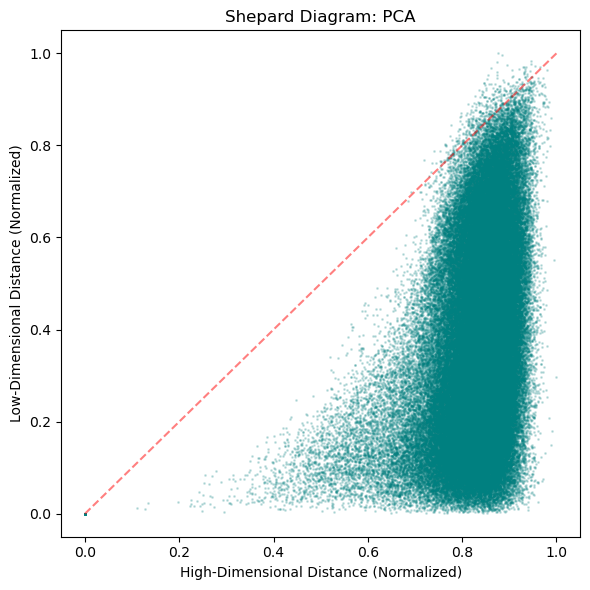

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_pca.png


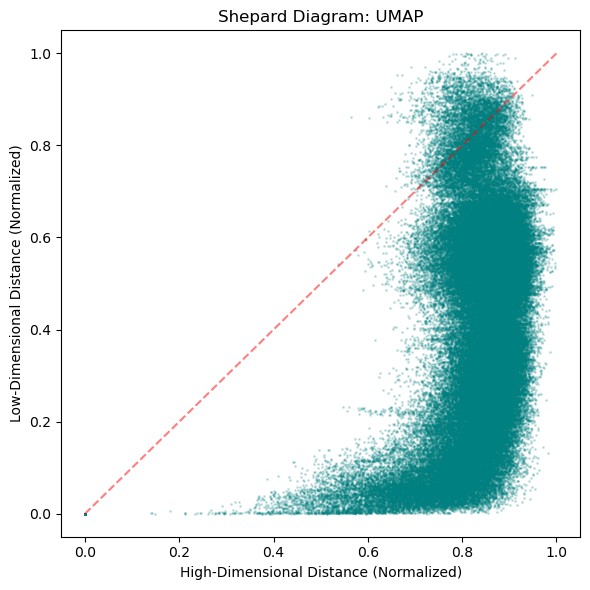

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_umap.png


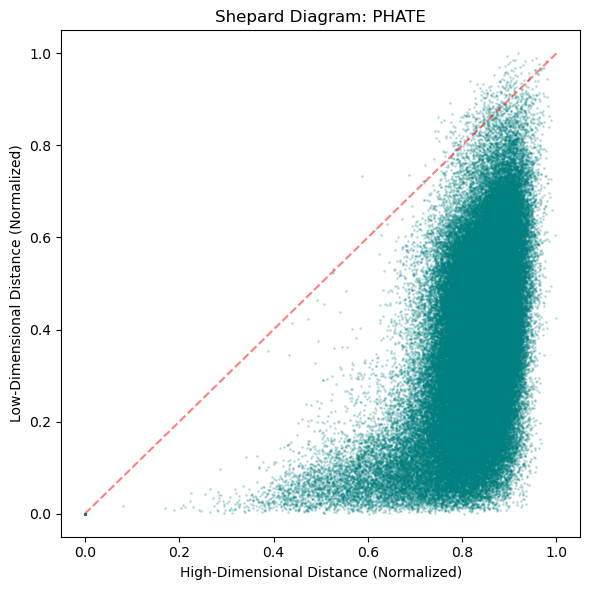

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_phate.png


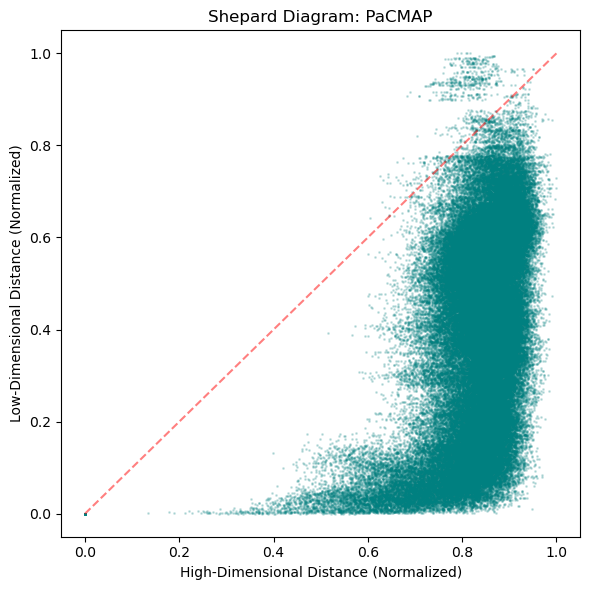

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_pacmap.png


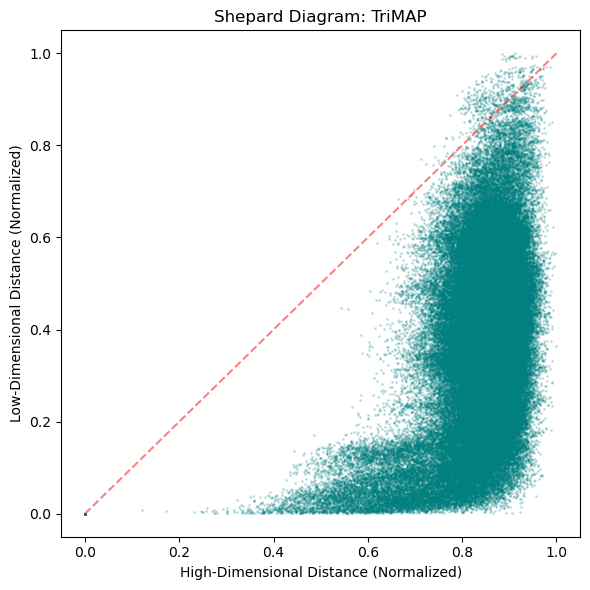

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_trimap.png


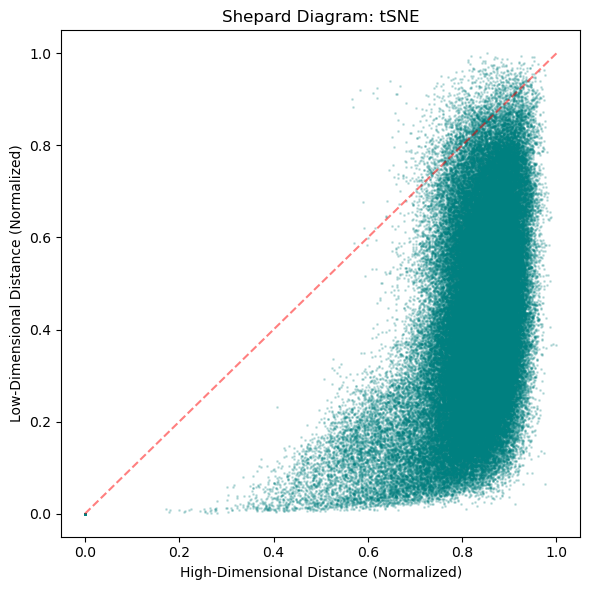

Saved: intermediate_data/sentence-transformers/all-MiniLM-L6-v2_results/shepard_Energy_Ecosystems_and_Humans_hierarchy_t1.0_maxsub3_depth5_synonyms0_noise0.25_random_tsne.png


In [9]:
def plot_shepard(x_high, x_low, name, sample_size=500):
    indices = np.random.choice(len(x_high), min(sample_size, len(x_high)), replace=False)

    d_high = pairwise_distances(x_high[indices]).flatten()
    d_low  = pairwise_distances(x_low[indices]).flatten()

    d_high = d_high / np.max(d_high)
    d_low  = d_low  / np.max(d_low)

    plt.figure(figsize=(6, 6))
    plt.scatter(d_high, d_low, alpha=0.1, s=1, color='teal')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', alpha=0.5)
    plt.title(f"Shepard Diagram: {name}")
    plt.xlabel("High-Dimensional Distance (Normalized)")
    plt.ylabel("Low-Dimensional Distance (Normalized)")
    plt.tight_layout()

    filename = os.path.join(shepard_dir, f"shepard_{stem}_{name.lower()}.png")
    plt.savefig(filename, dpi=300)
    plt.show()
    return filename

for name, x_low_2d in reductions.items():
    f = plot_shepard(x_high_sub, x_low_2d, name)
    print(f"Saved: {f}")

## 6. Results

Results using `all-MiniLM-L6-v2` and `Qwen3-Embedding-0.6B` embeddings projected natively to 2D. DEMaP uses min-connected K (smallest K where geodesic matrix has no inf values).

---

### Energy Ecosystems and Humans: maxsub5, depth3

**Clean**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7813 | 0.8738 | 0.4969 | 0.4815 | 0.7821 | 0.8907 | 0.4966 | 0.5782 |
| UMAP | 0.9443 | 0.9285 | 0.4169 | 0.6364 | 0.9623 | 0.9453 | 0.4766 | 0.7440 |
| PHATE | 0.8350 | 0.9112 | 0.4328 | 0.6872 | 0.8538 | 0.9263 | 0.4616 | 0.7463 |
| PaCMAP | 0.9376 | 0.9200 | 0.3846 | 0.6068 | 0.9586 | 0.9313 | 0.4286 | 0.6365 |
| TriMAP | 0.9317 | 0.9190 | 0.3053 | 0.5569 | 0.9544 | 0.9450 | 0.4536 | 0.7263 |
| tSNE | 0.9577 | 0.9277 | 0.4285 | 0.6103 | 0.9697 | 0.9445 | 0.4776 | 0.7046 |

**25% noise**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7559 | 0.8760 | 0.3044 | 0.2899 | 0.7663 | 0.8818 | 0.3671 | 0.3401 |
| UMAP | 0.9454 | 0.9341 | 0.4014 | 0.5895 | 0.9565 | 0.9475 | 0.4549 | 0.6711 |
| PHATE | 0.8107 | 0.9041 | 0.3166 | 0.5528 | 0.8465 | 0.9002 | 0.4344 | 0.6446 |
| PaCMAP | 0.9358 | 0.9087 | 0.2163 | 0.3602 | 0.9526 | 0.9337 | 0.3873 | 0.5038 |
| TriMAP | 0.9357 | 0.9204 | 0.2607 | 0.4037 | 0.9518 | 0.9402 | 0.4002 | 0.5672 |
| tSNE | 0.9575 | 0.9286 | 0.306 | 0.5241 | 0.9686 | 0.9446 | 0.4271 | 0.599 |

**50% noise**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7592 | 0.8879 | 0.3919 | 0.4418 | 0.7817 | 0.8919 | 0.4645 | 0.4475 |
| UMAP | 0.9453 | 0.9399 | 0.4312 | 0.6729 | 0.9520 | 0.9472 | 0.5567 | 0.7054 |
| PHATE | 0.7748 | 0.9029 | 0.3218 | 0.5560 | 0.8191 | 0.9108 | 0.4760 | 0.5858 |
| PaCMAP | 0.9364 | 0.9342 | 0.4070 | 0.6054 | 0.9464 | 0.9390 | 0.4676 | 0.5604 |
| TriMAP | 0.9364 | 0.9286 | 0.2356 | 0.4520 | 0.9493 | 0.9427 | 0.4359 | 0.5383 |
| tSNE | 0.957 | 0.9357 | 0.3488 | 0.5819 | 0.9669 | 0.9462 | 0.4705 | 0.5978 |

---

### Energy Ecosystems and Humans: maxsub3, depth5

**Clean**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7917 | 0.8953 | 0.5318 | 0.4164 | 0.8018 | 0.9082 | 0.5710 | 0.5089 |
| UMAP | 0.9700 | 0.9582 | 0.5100 | 0.5999 | 0.9756 | 0.9648 | 0.5701 | 0.7081 |
| PHATE | 0.8292 | 0.9115 | 0.4434 | 0.5282 | 0.8461 | 0.9250 | 0.4756 | 0.6326 |
| PaCMAP | 0.9567 | 0.9435 | 0.4876 | 0.5384 | 0.9636 | 0.9548 | 0.5185 | 0.6212 |
| TriMAP | 0.9519 | 0.9529 | 0.4730 | 0.5186 | 0.9617 | 0.9594 | 0.5150 | 0.6154 |
| tSNE | 0.975 | 0.9608 | 0.5301 | 0.6146 | 0.9797 | 0.9614 | 0.51 | 0.6402 |

**25% noise**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7816 | 0.8972 | 0.3488 | 0.1903 | 0.7953 | 0.9097 | 0.4278 | 0.2818 |
| UMAP | 0.9609 | 0.9577 | 0.2597 | 0.3230 | 0.9718 | 0.9634 | 0.4153 | 0.4946 |
| PHATE | 0.8556 | 0.9442 | 0.4422 | 0.5704 | 0.8440 | 0.9317 | 0.4689 | 0.6162 |
| PaCMAP | 0.9531 | 0.9535 | 0.3828 | 0.3801 | 0.9602 | 0.9538 | 0.3842 | 0.4115 |
| TriMAP | 0.9518 | 0.9526 | 0.3367 | 0.3263 | 0.9552 | 0.9592 | 0.4229 | 0.4488 |
| tSNE | 0.9743 | 0.961 | 0.4102 | 0.424 | 0.9789 | 0.9626 | 0.4214 | 0.491 |

**50% noise**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7831 | 0.9039 | 0.3952 | 0.1927 | 0.8053 | 0.9128 | 0.5161 | 0.2734 |
| UMAP | 0.9578 | 0.9561 | 0.3633 | 0.3686 | 0.9580 | 0.9565 | 0.5006 | 0.4917 |
| PHATE | 0.8848 | 0.9503 | 0.3928 | 0.4449 | 0.8933 | 0.9494 | 0.5461 | 0.5616 |
| PaCMAP | 0.9428 | 0.9462 | 0.3798 | 0.3388 | 0.9451 | 0.9434 | 0.4890 | 0.4029 |
| TriMAP | 0.9464 | 0.9484 | 0.3495 | 0.2709 | 0.9492 | 0.9483 | 0.4875 | 0.3854 |
| tSNE | 0.9705 | 0.9557 | 0.4107 | 0.3721 | 0.9724 | 0.9554 | 0.5212 | 0.4895 |

---

### Offshore Energy Impacts on Fisheries: maxsub5, depth3

**Clean**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7611 | 0.8643 | 0.4614 | 0.3375 | 0.7553 | 0.8639 | 0.5329 | 0.2733 |
| UMAP | 0.9424 | 0.9242 | 0.3387 | 0.5340 | 0.9414 | 0.9240 | 0.3961 | 0.5678 |
| PHATE | 0.8135 | 0.9015 | 0.4023 | 0.6195 | 0.8261 | 0.9133 | 0.4689 | 0.6253 |
| PaCMAP | 0.9389 | 0.9161 | 0.3638 | 0.5334 | 0.9401 | 0.9114 | 0.3175 | 0.4598 |
| TriMAP | 0.9307 | 0.9240 | 0.3647 | 0.5122 | 0.9362 | 0.9072 | 0.2604 | 0.4280 |
| tSNE | 0.9539 | 0.9227 | 0.4529 | 0.5327 | 0.9563 | 0.9241 | 0.4635 | 0.4996 |

**25% noise**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7357 | 0.8712 | 0.4575 | 0.3342 | 0.7502 | 0.8822 | 0.4125 | 0.1961 |
| UMAP | 0.9367 | 0.9325 | 0.2136 | 0.4711 | 0.9414 | 0.9353 | 0.3152 | 0.4296 |
| PHATE | 0.7804 | 0.9130 | 0.2375 | 0.5860 | 0.8062 | 0.9186 | 0.3905 | 0.5170 |
| PaCMAP | 0.9284 | 0.9185 | 0.1385 | 0.3713 | 0.9329 | 0.9131 | 0.2366 | 0.2922 |
| TriMAP | 0.9319 | 0.9231 | 0.1527 | 0.3311 | 0.9377 | 0.9203 | 0.1946 | 0.2444 |
| tSNE | 0.9526 | 0.9362 | 0.3837 | 0.5104 | 0.9574 | 0.9383 | 0.4123 | 0.4085 |

**50% noise**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7309 | 0.8827 | 0.4575 | 0.4458 | 0.7779 | 0.8935 | 0.5397 | 0.4264 |
| UMAP | 0.9314 | 0.9417 | 0.2278 | 0.4713 | 0.9454 | 0.9422 | 0.3485 | 0.5909 |
| PHATE | 0.7447 | 0.9068 | 0.1924 | 0.5483 | 0.7764 | 0.8977 | 0.3857 | 0.5419 |
| PaCMAP | 0.9202 | 0.9252 | 0.2597 | 0.4208 | 0.9396 | 0.9302 | 0.4004 | 0.4688 |
| TriMAP | 0.9301 | 0.9317 | 0.2027 | 0.3940 | 0.9457 | 0.9346 | 0.3918 | 0.4938 |
| tSNE | 0.9496 | 0.9412 | 0.3118 | 0.5148 | 0.9635 | 0.9453 | 0.5051 | 0.5742 |

---

### Offshore Energy Impacts on Fisheries: maxsub3, depth5

**Clean**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7815 | 0.8887 | 0.5454 | 0.4169 | 0.7616 | 0.8935 | 0.5710 | 0.4761 |
| UMAP | 0.9691 | 0.9604 | 0.4734 | 0.6769 | 0.9684 | 0.9600 | 0.4749 | 0.7249 |
| PHATE | 0.8702 | 0.9524 | 0.5101 | 0.7283 | 0.8737 | 0.9512 | 0.4864 | 0.7536 |
| PaCMAP | 0.9516 | 0.9510 | 0.4320 | 0.5926 | 0.9548 | 0.9529 | 0.5082 | 0.6520 |
| TriMAP | 0.9475 | 0.9501 | 0.4041 | 0.5829 | 0.9520 | 0.9560 | 0.4567 | 0.6991 |
| tSNE | 0.9751 | 0.9563 | 0.4276 | 0.5701 | 0.9756 | 0.9575 | 0.5396 | 0.6221 |

**25% noise**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7459 | 0.8920 | 0.3853 | 0.2013 | 0.7671 | 0.9051 | 0.4732 | 0.3984 |
| UMAP | 0.9638 | 0.9630 | 0.3877 | 0.5500 | 0.9650 | 0.9620 | 0.4154 | 0.6679 |
| PHATE | 0.8782 | 0.9583 | 0.4885 | 0.6643 | 0.8867 | 0.9582 | 0.4563 | 0.6985 |
| PaCMAP | 0.9460 | 0.9552 | 0.3104 | 0.4152 | 0.9524 | 0.9544 | 0.3977 | 0.5571 |
| TriMAP | 0.9432 | 0.9534 | 0.2916 | 0.4234 | 0.9483 | 0.9550 | 0.3524 | 0.5751 |
| tSNE | 0.9731 | 0.9596 | 0.4265 | 0.5112 | 0.9746 | 0.9608 | 0.4846 | 0.5308 |

**50% noise**

| Method | T (MiniLM) | C (MiniLM) | Sp (MiniLM) | DEMaP (MiniLM) | T (Qwen) | C (Qwen) | Sp (Qwen) | DEMaP (Qwen) |
|--------|-----------|-----------|------------|---------------|---------|---------|----------|-------------|
| PCA | 0.7398 | 0.9013 | 0.4243 | 0.3017 | 0.7598 | 0.9046 | 0.4651 | 0.3356 |
| UMAP | 0.9577 | 0.9626 | 0.3920 | 0.5269 | 0.9578 | 0.9623 | 0.4056 | 0.5988 |
| PHATE | 0.8668 | 0.9571 | 0.4336 | 0.6266 | 0.8789 | 0.9538 | 0.4690 | 0.6149 |
| PaCMAP | 0.9311 | 0.9551 | 0.3591 | 0.4763 | 0.9380 | 0.9511 | 0.4489 | 0.5427 |
| TriMAP | 0.9354 | 0.9527 | 0.2941 | 0.4271 | 0.9412 | 0.9499 | 0.3296 | 0.5024 |
| tSNE | 0.9714 | 0.9583 | 0.4512 | 0.5283 | 0.9704 | 0.9586 | 0.4746 | 0.5846 |

## 7. Discussion

**UMAP, PaCMAP, and TriMAP consistently lead on Trustworthiness:** UMAP reaches 0.93-0.98, PaCMAP 0.92-0.96, and TriMAP 0.93-0.96 across all configs and noise levels for both embedding models. These optimization-based methods pack similar points tightly in 2D, preserving local neighborhoods effectively. PHATE and PCA score lower on Trustworthiness (0.73-0.89) but are more competitive on DEMaP.

**t-SNE Trustworthiness is consistently strong across all configs:** Using scikit-learn TSNE with identical parameters across all 24 configs, t-SNE achieves 0.95–0.98 Trustworthiness across both depth configs and both embedding models, comparable to UMAP and PaCMAP. However, t-SNE scores lower on global structure metrics: Spearman Correlation ranges 0.31–0.54 and DEMaP ranges 0.37–0.70, reflecting its emphasis on local neighborhood preservation over global distance fidelity.

**PHATE leads or ties on DEMaP for depth5 configs:** On Offshore depth5 clean, PHATE reaches DEMaP 0.7283 (MiniLM) and 0.7536 (Qwen), the highest of any method. PHATE's diffusion geometry is well-suited to capturing branching hierarchical structure that survives compression to 2D better than local-neighborhood methods.

**Qwen3-Embedding-0.6B consistently outperforms MiniLM on DEMaP:** Across nearly all configs, Qwen embeddings yield higher DEMaP scores. For example, Energy maxsub5 depth3 clean: UMAP DEMaP 0.744 vs 0.636, PHATE 0.746 vs 0.687. Qwen's larger model capacity appears to produce embeddings with more recoverable manifold structure.

**Noise degrades DEMaP and Spearman but not Trustworthiness or Continuity:** Even at 50% noise, Trustworthiness and Continuity remain above 0.90 for UMAP, PaCMAP, and TriMAP. DEMaP drops significantly. For example, Energy maxsub3 depth5 UMAP: 0.600 clean to 0.323 at 25% noise for MiniLM. This confirms that global structure is more sensitive to noise than local neighborhoods.

**TriMAP scores are generally between PaCMAP and UMAP on DEMaP:** TriMAP optimizes triplet constraints which preserve relative ordering of distances, placing it between the aggressive local compression of UMAP and the global structure of PHATE. On Spearman, TriMAP is often weaker than PaCMAP and UMAP, suggesting it sacrifices raw distance correlation for relative ordering.

**Depth5 configs have a higher DEMaP floor than depth3 configs:** Deeper hierarchies create richer topic geometry that is more uniformly recoverable. For clean depth5 configs, the lowest method DEMaP is 0.42 (PCA), while depth3 drops as low as 0.27. Peak DEMaP is similar between the two: Offshore depth5 clean PHATE reaches 0.73-0.75, and Energy depth3 clean PHATE reaches 0.69-0.75. The main difference is consistency, not ceiling.